# Comprehensive Feature Selection for Delinquency Prediction

This notebook implements a **multi-stage feature selection pipeline** optimized for tree-based models:

1. **Variance Threshold** - Remove low-variance features
2. **Correlation Filtering** - Remove highly correlated features
3. **Tree-Based Feature Importance** - Rank by model importance
4. **Mutual Information** - Capture non-linear relationships
5. **SHAP Values** - Understand feature contributions
6. **Permutation Importance** - Real predictive power
7. **Stability Selection** - Choose robust features

**Goal**: Identify the most predictive and stable features for delinquency risk.

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from scipy.cluster import hierarchy
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Imports complete!")

Imports complete!


## Load and Prepare Data

**Note:** Features are pre-computed and loaded from `features.csv` for speed.

In [2]:
# Load features from CSV
print("Loading features from CSV...")
features_df = pd.read_csv('features.csv', index_col=0)

print(f"\nTotal features: {features_df.shape[1] - 1}")
print(f"Total consumers: {features_df.shape[0]}")
print(f"Delinquency rate: {features_df['DQ_TARGET'].mean():.2%}")
print("\nFeatures loaded successfully!")

Loading features from CSV...

Total features: 216
Total consumers: 12900
Delinquency rate: 8.86%

Features loaded successfully!


In [3]:
# Prepare X and y
df_clean = features_df[features_df["DQ_TARGET"].notna()].copy()
y = df_clean["DQ_TARGET"].astype(int)
X = df_clean.drop(columns=["DQ_TARGET"]).select_dtypes(include=[np.number]).fillna(0)

print(f"X shape: {X.shape}")
print(f"y distribution: {y.value_counts().to_dict()}")

# Train/val split
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape}, Val: {X_val.shape}")

X shape: (10317, 216)
y distribution: {0: 9403, 1: 914}

Train: (7737, 216), Val: (2580, 216)


## Stage 1: Variance Threshold

Remove features with very low variance (near-constant values).

In [4]:
from sklearn.feature_selection import VarianceThreshold

# Remove features with < 1% variance
selector_var = VarianceThreshold(threshold=0.01)
selector_var.fit(X_train)

features_stage1 = X_train.columns[selector_var.get_support()].tolist()
removed_var = set(X_train.columns) - set(features_stage1)

print(f"Features removed (low variance): {len(removed_var)}")
print(f"Features remaining: {len(features_stage1)}")

if removed_var:
    print(f"\nRemoved: {list(removed_var)[:10]}...")

X_train_s1 = X_train[features_stage1]
X_val_s1 = X_val[features_stage1]

Features removed (low variance): 2
Features remaining: 214

Removed: ['debit__total__all', 'tx__max_debit__all']...


## Stage 2: Correlation Filtering

Remove highly correlated features (keep one from each correlated group).

In [5]:
# Calculate correlation matrix
corr_matrix = X_train_s1.corr().abs()

# Find pairs of highly correlated features
threshold_corr = 0.95
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Find features with correlation > threshold
to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > threshold_corr)]

print(f"Features removed (high correlation > {threshold_corr}): {len(to_drop_corr)}")
if to_drop_corr:
    print(f"Examples: {to_drop_corr[:5]}")

features_stage2 = [f for f in features_stage1 if f not in to_drop_corr]
print(f"Features remaining: {len(features_stage2)}")

X_train_s2 = X_train_s1[features_stage2]
X_val_s2 = X_val_s1[features_stage2]

Features removed (high correlation > 0.95): 39
Examples: ['balance__min__30d', 'cashflow__volatility__30d', 'balance__mean__60d', 'balance__min__60d', 'balance__pct_negative__60d']
Features remaining: 175


## Stage 3: Baseline Model Performance

Train a baseline model to establish performance before further selection.

In [8]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, classification_report

# Baseline model with all remaining features
# Using GradientBoostingClassifier which has feature_importances_ attribute
model_baseline = GradientBoostingClassifier(
    max_depth=6,
    n_estimators=300,
    learning_rate=0.05,
    min_samples_leaf=50,
    random_state=42,
    subsample=0.8,
    verbose=1
)

model_baseline.fit(X_train_s2, y_train)

y_val_prob = model_baseline.predict_proba(X_val_s2)[:, 1]
y_val_pred = model_baseline.predict(X_val_s2)

baseline_auc = roc_auc_score(y_val, y_val_prob)

print("="*60)
print("BASELINE MODEL PERFORMANCE")
print("="*60)
print(f"Features used: {X_train_s2.shape[1]}")
print(f"Validation AUC: {baseline_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

      Iter       Train Loss      OOB Improve   Remaining Time 
         1           0.5856           0.0086            1.14m
         2           0.5724           0.0147            1.07m
         3           0.5622           0.0176            1.06m
         4           0.5431          -0.0213            1.05m
         5           0.5377           0.0204            1.04m
         6           0.5431           0.0668            1.04m
         7           0.5326          -0.0064            1.04m
         8           0.5170          -0.0226            1.03m
         9           0.5108           0.0081            1.03m
        10           0.5051           0.0097            1.02m
        20           0.4497           0.0023           59.69s
        30           0.4262          -0.0116           58.19s
        40           0.3869          -0.0105           56.22s
        50           0.3765           0.0253           54.30s
        60           0.3626           0.0269           52.15s
       

## Stage 4: Tree-Based Feature Importance

Use built-in feature importance from gradient boosting.

Top 20 Features by Tree Importance:
                               feature  importance
7                          n_days__all    0.068453
6          balance__pct_below_500__all    0.038852
159                    total_fees__90d    0.023966
0                 balance__median__all    0.023656
2                    balance__max__all    0.020614
145       essentials_spend__total__all    0.019986
115                  cat_1__cat_n__90d    0.017823
3                    balance__std__all    0.017593
13                           n_tx__30d    0.016825
98          cat_19__cat_net_total__90d    0.016567
1                    balance__min__all    0.015600
8                   balance__mean__30d    0.015009
88           cat_4__cat_net_total__90d    0.013865
148  discretionary__pct_of_income__all    0.013027
122                 cat_12__cat_n__90d    0.012560
9                    balance__std__30d    0.012426
126                 cat_17__cat_n__90d    0.012406
54                   cat_0__cat_n__all    0.01

Top 20 Features by Tree Importance:
                               feature  importance
7                          n_days__all    0.068453
6          balance__pct_below_500__all    0.038852
159                    total_fees__90d    0.023966
0                 balance__median__all    0.023656
2                    balance__max__all    0.020614
145       essentials_spend__total__all    0.019986
115                  cat_1__cat_n__90d    0.017823
3                    balance__std__all    0.017593
13                           n_tx__30d    0.016825
98          cat_19__cat_net_total__90d    0.016567
1                    balance__min__all    0.015600
8                   balance__mean__30d    0.015009
88           cat_4__cat_net_total__90d    0.013865
148  discretionary__pct_of_income__all    0.013027
122                 cat_12__cat_n__90d    0.012560
9                    balance__std__30d    0.012426
126                 cat_17__cat_n__90d    0.012406
54                   cat_0__cat_n__all    0.01

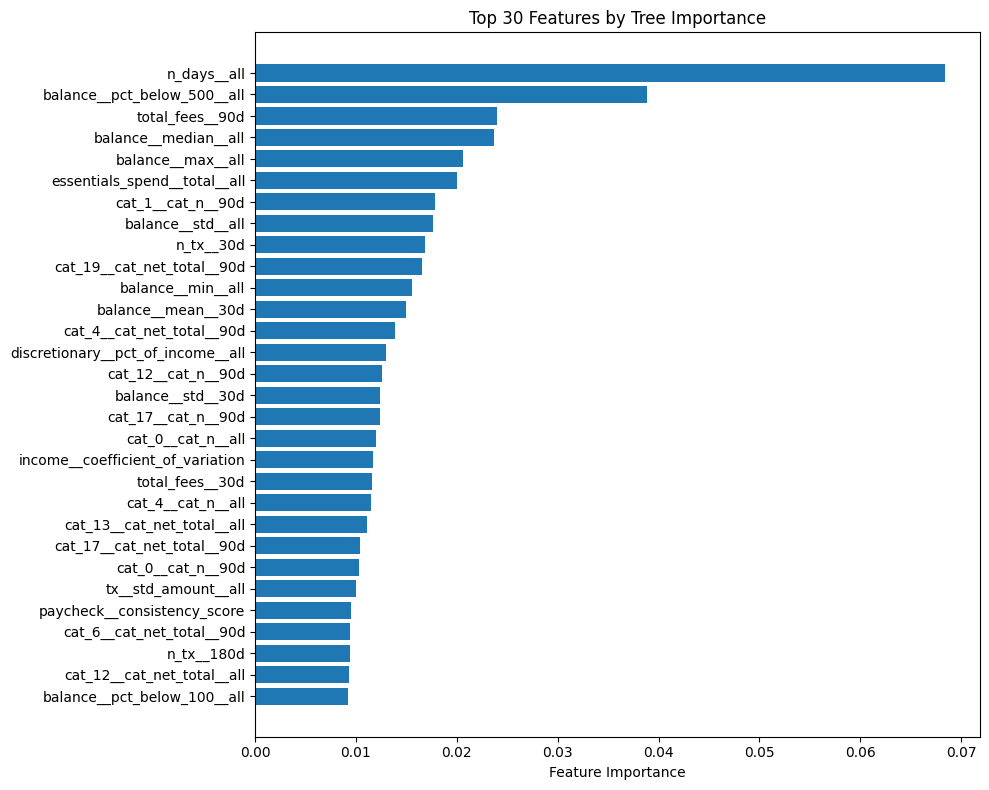

In [9]:
# Get feature importances
importance_df = pd.DataFrame({
    'feature': X_train_s2.columns,
    'importance': model_baseline.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 Features by Tree Importance:")
print(importance_df.head(20).to_string())

# Plot top 30
plt.figure(figsize=(10, 8))
top_30 = importance_df.head(30)
plt.barh(range(len(top_30)), top_30['importance'])
plt.yticks(range(len(top_30)), top_30['feature'])
plt.xlabel('Feature Importance')
plt.title('Top 30 Features by Tree Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Stage 5: Permutation Importance

Measure the actual impact on model performance when features are shuffled.

Computing permutation importance (this may take a few minutes)...

Top 20 Features by Permutation Importance:
                              feature  importance_mean  importance_std
7                         n_days__all         0.055132        0.006770
115                 cat_1__cat_n__90d         0.011919        0.001553
126                cat_17__cat_n__90d         0.007395        0.002204
159                   total_fees__90d         0.007293        0.001965
145      essentials_spend__total__all         0.007095        0.002745
98         cat_19__cat_net_total__90d         0.005460        0.001160
0                balance__median__all         0.004878        0.001969
1                   balance__min__all         0.004755        0.001778
122                cat_12__cat_n__90d         0.004102        0.002502
96         cat_17__cat_net_total__90d         0.003725        0.000642
32         cat_12__cat_net_total__all         0.003713        0.000773
8                  balance__mean__30d 

Computing permutation importance (this may take a few minutes)...

Top 20 Features by Permutation Importance:
                              feature  importance_mean  importance_std
7                         n_days__all         0.055132        0.006770
115                 cat_1__cat_n__90d         0.011919        0.001553
126                cat_17__cat_n__90d         0.007395        0.002204
159                   total_fees__90d         0.007293        0.001965
145      essentials_spend__total__all         0.007095        0.002745
98         cat_19__cat_net_total__90d         0.005460        0.001160
0                balance__median__all         0.004878        0.001969
1                   balance__min__all         0.004755        0.001778
122                cat_12__cat_n__90d         0.004102        0.002502
96         cat_17__cat_net_total__90d         0.003725        0.000642
32         cat_12__cat_net_total__all         0.003713        0.000773
8                  balance__mean__30d 

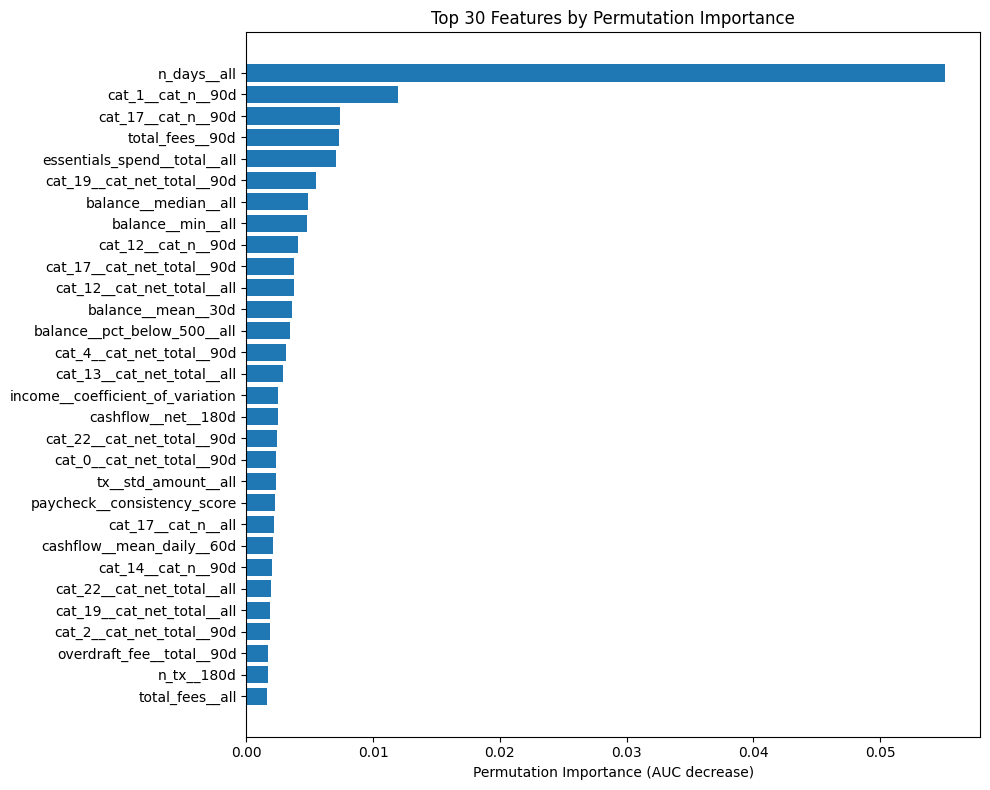

In [10]:
from sklearn.inspection import permutation_importance

print("Computing permutation importance (this may take a few minutes)...")

perm_importance = permutation_importance(
    model_baseline, 
    X_val_s2, 
    y_val,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc',
    n_jobs=-1
)

perm_importance_df = pd.DataFrame({
    'feature': X_train_s2.columns,
    'importance_mean': perm_importance.importances_mean,
    'importance_std': perm_importance.importances_std
}).sort_values('importance_mean', ascending=False)

print("\nTop 20 Features by Permutation Importance:")
print(perm_importance_df.head(20).to_string())

# Plot
plt.figure(figsize=(10, 8))
top_30_perm = perm_importance_df.head(30)
plt.barh(range(len(top_30_perm)), top_30_perm['importance_mean'])
plt.yticks(range(len(top_30_perm)), top_30_perm['feature'])
plt.xlabel('Permutation Importance (AUC decrease)')
plt.title('Top 30 Features by Permutation Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Stage 6: SHAP Values

Use SHAP to understand feature contributions and interactions.

Computing SHAP values (this may take several minutes)...

Top 20 Features by SHAP Importance:
                              feature  shap_importance
7                         n_days__all         0.372526
8                  balance__mean__30d         0.186066
6         balance__pct_below_500__all         0.173169
0                balance__median__all         0.158778
159                   total_fees__90d         0.124256
115                 cat_1__cat_n__90d         0.108513
171       paycheck__consistency_score         0.105893
126                cat_17__cat_n__90d         0.103196
145      essentials_spend__total__all         0.088511
122                cat_12__cat_n__90d         0.081500
54                  cat_0__cat_n__all         0.078496
168  income__coefficient_of_variation         0.078289
39         cat_20__cat_net_total__all         0.076067
1                   balance__min__all         0.073974
58                  cat_4__cat_n__all         0.072655
3                   balanc

Computing SHAP values (this may take several minutes)...

Top 20 Features by SHAP Importance:
                              feature  shap_importance
7                         n_days__all         0.372526
8                  balance__mean__30d         0.186066
6         balance__pct_below_500__all         0.173169
0                balance__median__all         0.158778
159                   total_fees__90d         0.124256
115                 cat_1__cat_n__90d         0.108513
171       paycheck__consistency_score         0.105893
126                cat_17__cat_n__90d         0.103196
145      essentials_spend__total__all         0.088511
122                cat_12__cat_n__90d         0.081500
54                  cat_0__cat_n__all         0.078496
168  income__coefficient_of_variation         0.078289
39         cat_20__cat_net_total__all         0.076067
1                   balance__min__all         0.073974
58                  cat_4__cat_n__all         0.072655
3                   balanc

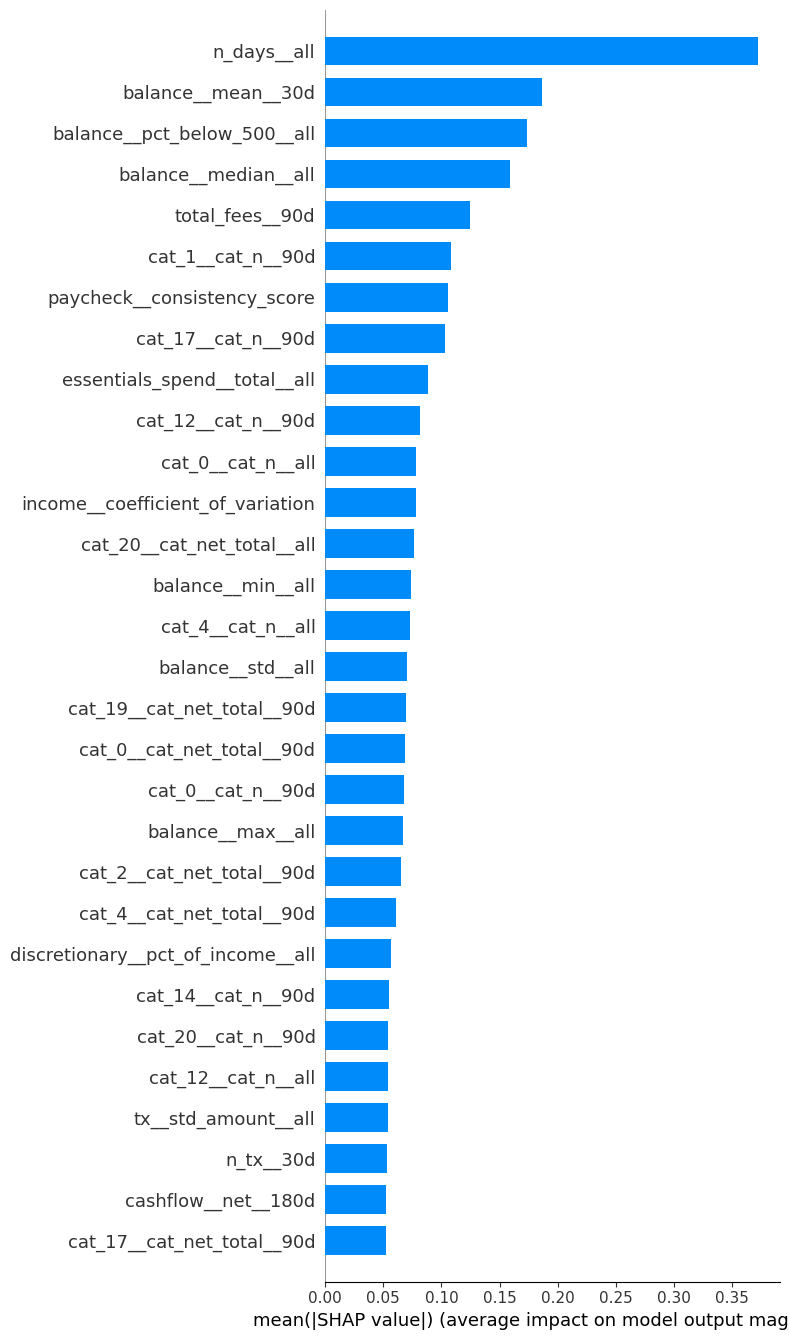

Computing SHAP values (this may take several minutes)...

Top 20 Features by SHAP Importance:
                              feature  shap_importance
7                         n_days__all         0.372526
8                  balance__mean__30d         0.186066
6         balance__pct_below_500__all         0.173169
0                balance__median__all         0.158778
159                   total_fees__90d         0.124256
115                 cat_1__cat_n__90d         0.108513
171       paycheck__consistency_score         0.105893
126                cat_17__cat_n__90d         0.103196
145      essentials_spend__total__all         0.088511
122                cat_12__cat_n__90d         0.081500
54                  cat_0__cat_n__all         0.078496
168  income__coefficient_of_variation         0.078289
39         cat_20__cat_net_total__all         0.076067
1                   balance__min__all         0.073974
58                  cat_4__cat_n__all         0.072655
3                   balanc

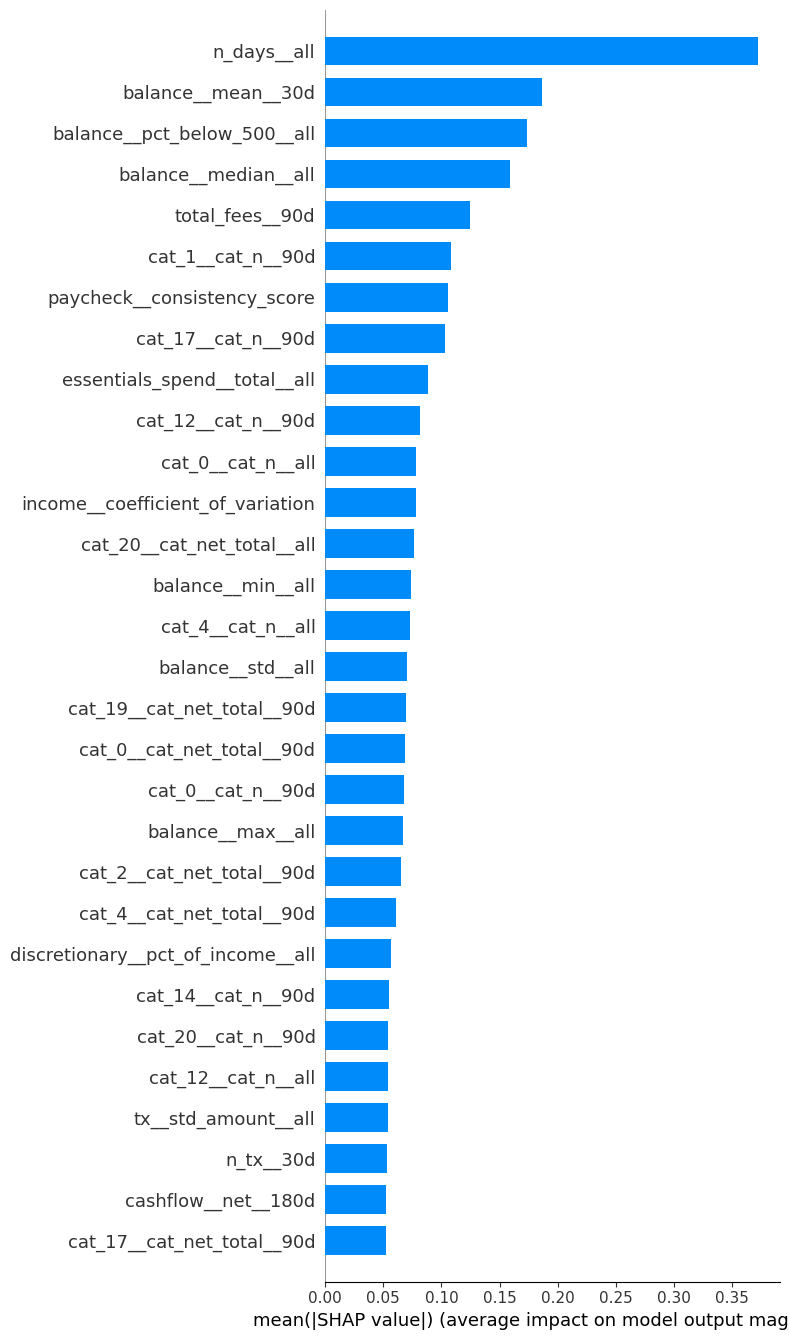

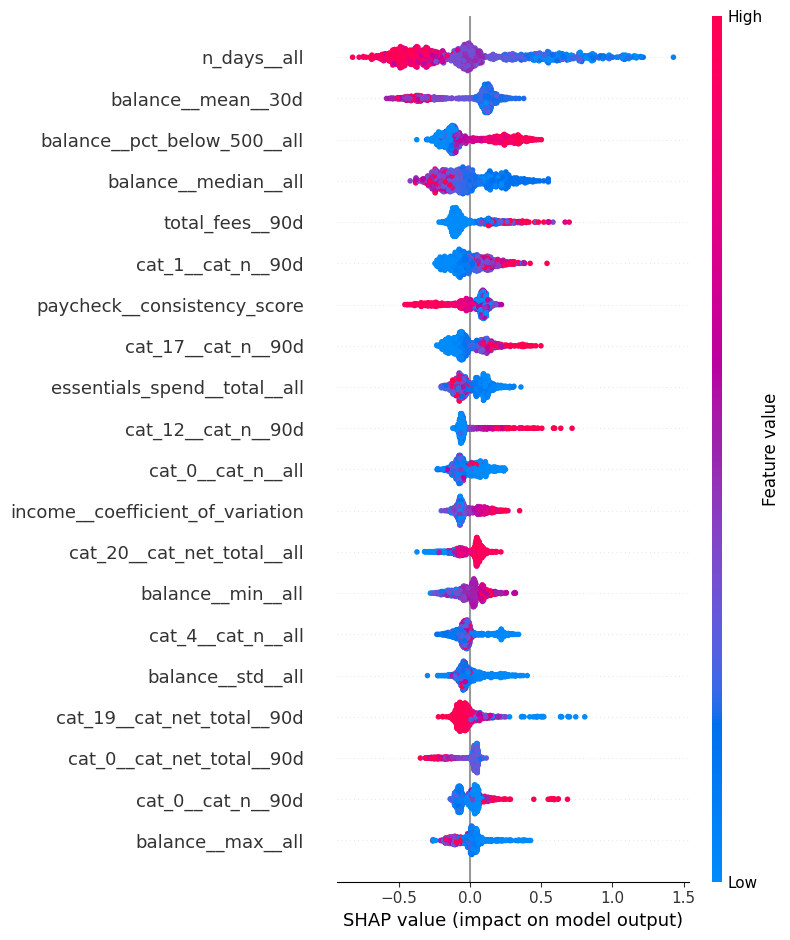

In [17]:
try:
    import shap
    
    print("Computing SHAP values (this may take several minutes)...")
    
    # Sample for faster computation
    sample_size = min(1000, len(X_val_s2))
    X_val_sample = X_val_s2.sample(n=sample_size, random_state=42)
    
    # Create explainer
    explainer = shap.TreeExplainer(model_baseline)
    shap_values = explainer.shap_values(X_val_sample)
    
    # If binary classification, take positive class
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
    
    # Calculate mean absolute SHAP values
    shap_importance = pd.DataFrame({
        'feature': X_val_sample.columns,
        'shap_importance': np.abs(shap_values).mean(axis=0)
    }).sort_values('shap_importance', ascending=False)
    
    print("\nTop 20 Features by SHAP Importance:")
    print(shap_importance.head(20).to_string())
    
    # Summary plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_val_sample, plot_type="bar", max_display=30, show=False)
    plt.tight_layout()
    plt.show()
    
    # Detailed summary plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_val_sample, max_display=20, show=False)
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("SHAP not installed. Install with: pip install shap")
    shap_importance = None

## Stage 7: Mutual Information

Capture non-linear relationships with the target.

Computing mutual information...

Top 20 Features by Mutual Information:
                                         feature  mi_score
0                           balance__median__all  0.020048
7                                    n_days__all  0.019318
8                             balance__mean__30d  0.015950
3                              balance__std__all  0.015043
6                    balance__pct_below_500__all  0.014351
159                              total_fees__90d  0.012267
158                              total_fees__30d  0.012141
2                              balance__max__all  0.011624
172         balance__min_before_income__avg__90d  0.011313
157                              total_fees__all  0.011160
15                             balance__std__60d  0.010965
102                   cat_23__cat_net_total__90d  0.010859
1                              balance__min__all  0.009981
5                    balance__pct_below_100__all  0.008838
156                    overdraft_fee__total

Computing mutual information...

Top 20 Features by Mutual Information:
                                         feature  mi_score
0                           balance__median__all  0.020048
7                                    n_days__all  0.019318
8                             balance__mean__30d  0.015950
3                              balance__std__all  0.015043
6                    balance__pct_below_500__all  0.014351
159                              total_fees__90d  0.012267
158                              total_fees__30d  0.012141
2                              balance__max__all  0.011624
172         balance__min_before_income__avg__90d  0.011313
157                              total_fees__all  0.011160
15                             balance__std__60d  0.010965
102                   cat_23__cat_net_total__90d  0.010859
1                              balance__min__all  0.009981
5                    balance__pct_below_100__all  0.008838
156                    overdraft_fee__total

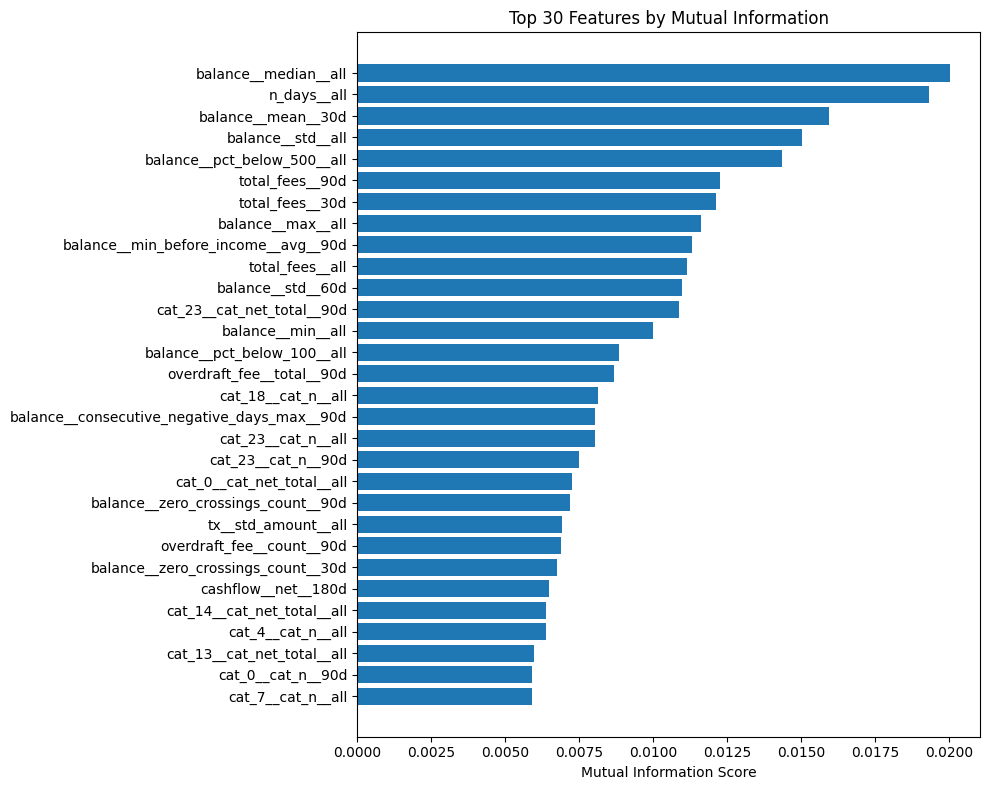

In [12]:
from sklearn.feature_selection import mutual_info_classif

print("Computing mutual information...")

mi_scores = mutual_info_classif(
    X_train_s2, 
    y_train, 
    discrete_features=False,
    random_state=42,
    n_neighbors=5
)

mi_df = pd.DataFrame({
    'feature': X_train_s2.columns,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

print("\nTop 20 Features by Mutual Information:")
print(mi_df.head(20).to_string())

# Plot
plt.figure(figsize=(10, 8))
top_30_mi = mi_df.head(30)
plt.barh(range(len(top_30_mi)), top_30_mi['mi_score'])
plt.yticks(range(len(top_30_mi)), top_30_mi['feature'])
plt.xlabel('Mutual Information Score')
plt.title('Top 30 Features by Mutual Information')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Stage 8: Consensus Feature Selection

Combine rankings from all methods to identify the most robust features.

In [13]:
# Normalize all importance scores to 0-1 range
def normalize_scores(df, score_col):
    """Normalize scores to 0-1 range."""
    scores = df[score_col].values
    return (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)

# Combine all rankings
consensus_df = pd.DataFrame({'feature': X_train_s2.columns})

# Add tree importance (normalized)
importance_df_norm = importance_df.copy()
importance_df_norm['tree_score'] = normalize_scores(importance_df_norm, 'importance')
consensus_df = consensus_df.merge(
    importance_df_norm[['feature', 'tree_score']], 
    on='feature', 
    how='left'
)

# Add permutation importance (normalized)
perm_importance_df_norm = perm_importance_df.copy()
perm_importance_df_norm['perm_score'] = normalize_scores(perm_importance_df_norm, 'importance_mean')
consensus_df = consensus_df.merge(
    perm_importance_df_norm[['feature', 'perm_score']], 
    on='feature', 
    how='left'
)

# Add mutual information (normalized)
mi_df_norm = mi_df.copy()
mi_df_norm['mi_score_norm'] = normalize_scores(mi_df_norm, 'mi_score')
consensus_df = consensus_df.merge(
    mi_df_norm[['feature', 'mi_score_norm']], 
    on='feature', 
    how='left'
)

# Add SHAP if available
if shap_importance is not None:
    shap_importance_norm = shap_importance.copy()
    shap_importance_norm['shap_score'] = normalize_scores(shap_importance_norm, 'shap_importance')
    consensus_df = consensus_df.merge(
        shap_importance_norm[['feature', 'shap_score']], 
        on='feature', 
        how='left'
    )
    # Weighted consensus (SHAP gets higher weight)
    consensus_df['consensus_score'] = (
        0.25 * consensus_df['tree_score'].fillna(0) +
        0.30 * consensus_df['perm_score'].fillna(0) +
        0.20 * consensus_df['mi_score_norm'].fillna(0) +
        0.25 * consensus_df['shap_score'].fillna(0)
    )
else:
    # Without SHAP
    consensus_df['consensus_score'] = (
        0.35 * consensus_df['tree_score'].fillna(0) +
        0.40 * consensus_df['perm_score'].fillna(0) +
        0.25 * consensus_df['mi_score_norm'].fillna(0)
    )

consensus_df = consensus_df.sort_values('consensus_score', ascending=False)

print("="*80)
print("TOP 50 FEATURES BY CONSENSUS RANKING")
print("="*80)
print(consensus_df.head(50).to_string())

# Save to CSV
consensus_df.to_csv('feature_importance_consensus.csv', index=False)
print("\n✓ Saved to 'feature_importance_consensus.csv'")

TOP 50 FEATURES BY CONSENSUS RANKING
                                         feature  tree_score  perm_score  mi_score_norm  consensus_score
7                                    n_days__all    1.000000    1.000000       0.963594         0.990898
0                           balance__median__all    0.345580    0.129618       1.000000         0.422800
6                    balance__pct_below_500__all    0.567566    0.104789       0.715841         0.419524
159                              total_fees__90d    0.350107    0.171437       0.611880         0.344082
8                             balance__mean__30d    0.219255    0.107783       0.795624         0.318758
3                              balance__std__all    0.257011    0.043617       0.750342         0.294986
115                            cat_1__cat_n__90d    0.260361    0.251561       0.289233         0.264059
1                              balance__min__all    0.227897    0.127484       0.497885         0.255229
2                 

## Stage 9: Test Different Feature Set Sizes

Evaluate model performance with different numbers of top features.

Features:  10 | AUC: 0.7583
Features:  20 | AUC: 0.7723
Features:  30 | AUC: 0.7997
Features:  50 | AUC: 0.8078
Features:  75 | AUC: 0.8061
Features: 100 | AUC: 0.8054
Features: 150 | AUC: 0.8059


Features:  10 | AUC: 0.7583
Features:  20 | AUC: 0.7723
Features:  30 | AUC: 0.7997
Features:  50 | AUC: 0.8078
Features:  75 | AUC: 0.8061
Features: 100 | AUC: 0.8054
Features: 150 | AUC: 0.8059


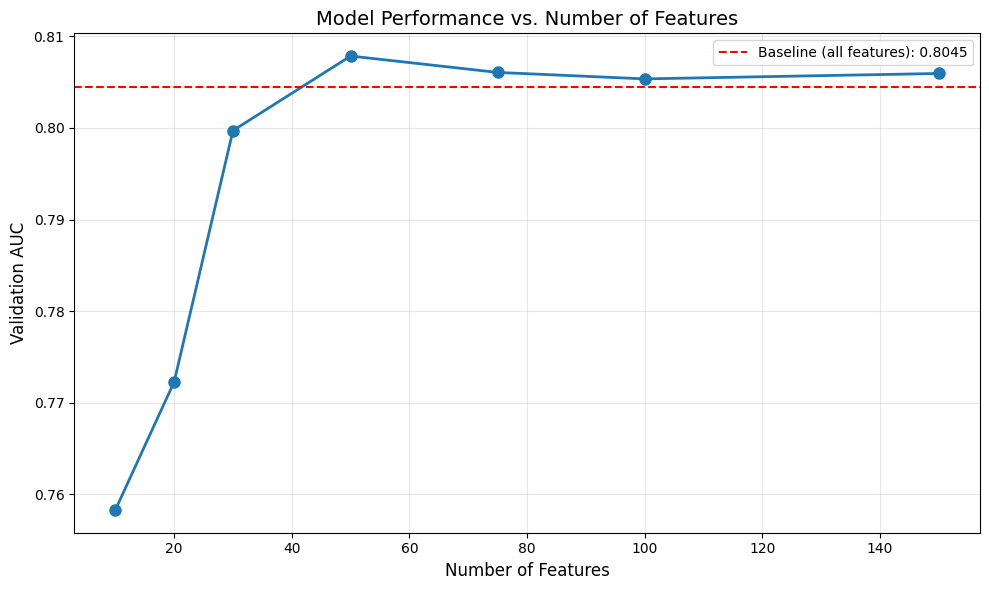


OPTIMAL: 50 features with AUC = 0.8078
(vs. baseline 175 features with AUC = 0.8045)


In [14]:
# Test different feature counts
feature_counts = [10, 20, 30, 50, 75, 100, 150, 200]
results = []

for n_features in feature_counts:
    if n_features > len(consensus_df):
        continue
    
    # Select top N features
    top_features = consensus_df.head(n_features)['feature'].tolist()
    
    X_train_subset = X_train_s2[top_features]
    X_val_subset = X_val_s2[top_features]
    
    # Train model
    model_subset = GradientBoostingClassifier(
        max_depth=6,
        n_estimators=300,
        learning_rate=0.05,
        min_samples_leaf=50,
        random_state=42,
        subsample=0.8
    )
    
    model_subset.fit(X_train_subset, y_train)
    y_val_prob_subset = model_subset.predict_proba(X_val_subset)[:, 1]
    auc_subset = roc_auc_score(y_val, y_val_prob_subset)
    
    results.append({
        'n_features': n_features,
        'auc': auc_subset
    })
    
    print(f"Features: {n_features:3d} | AUC: {auc_subset:.4f}")

results_df = pd.DataFrame(results)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(results_df['n_features'], results_df['auc'], marker='o', linewidth=2, markersize=8)
plt.axhline(y=baseline_auc, color='r', linestyle='--', label=f'Baseline (all features): {baseline_auc:.4f}')
plt.xlabel('Number of Features', fontsize=12)
plt.ylabel('Validation AUC', fontsize=12)
plt.title('Model Performance vs. Number of Features', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Find optimal number of features
best_idx = results_df['auc'].argmax()
best_n_features = results_df.iloc[best_idx]['n_features']
best_auc = results_df.iloc[best_idx]['auc']

print("\n" + "="*80)
print(f"OPTIMAL: {int(best_n_features)} features with AUC = {best_auc:.4f}")
print(f"(vs. baseline {X_train_s2.shape[1]} features with AUC = {baseline_auc:.4f})")
print("="*80)

## Final: Export Selected Features


Final 50 selected features:
 1. n_days__all
 2. balance__median__all
 3. balance__pct_below_500__all
 4. total_fees__90d
 5. balance__mean__30d
 6. balance__std__all
 7. cat_1__cat_n__90d
 8. balance__min__all
 9. balance__max__all
10. essentials_spend__total__all
11. total_fees__30d
12. total_fees__all
13. balance__std__60d
14. cat_23__cat_net_total__90d
15. balance__min_before_income__avg__90d
16. tx__std_amount__all
17. cat_13__cat_net_total__all
18. balance__pct_below_100__all
19. cat_4__cat_n__all
20. cashflow__net__180d
21. overdraft_fee__total__90d
22. cat_0__cat_n__all
23. cat_19__cat_net_total__90d
24. balance__std__30d
25. paycheck__consistency_score
26. cat_12__cat_n__90d
27. cat_4__cat_net_total__90d
28. cat_0__cat_n__90d
29. n_tx__30d
30. cat_23__cat_n__90d
31. cat_12__cat_net_total__all
32. cat_18__cat_net_total__all
33. cat_17__cat_n__90d
34. cat_18__cat_n__all
35. income__coefficient_of_variation
36. balance__zero_crossings_count__90d
37. cat_0__cat_net_total__all
38. 


Final 50 selected features:
 1. n_days__all
 2. balance__median__all
 3. balance__pct_below_500__all
 4. total_fees__90d
 5. balance__mean__30d
 6. balance__std__all
 7. cat_1__cat_n__90d
 8. balance__min__all
 9. balance__max__all
10. essentials_spend__total__all
11. total_fees__30d
12. total_fees__all
13. balance__std__60d
14. cat_23__cat_net_total__90d
15. balance__min_before_income__avg__90d
16. tx__std_amount__all
17. cat_13__cat_net_total__all
18. balance__pct_below_100__all
19. cat_4__cat_n__all
20. cashflow__net__180d
21. overdraft_fee__total__90d
22. cat_0__cat_n__all
23. cat_19__cat_net_total__90d
24. balance__std__30d
25. paycheck__consistency_score
26. cat_12__cat_n__90d
27. cat_4__cat_net_total__90d
28. cat_0__cat_n__90d
29. n_tx__30d
30. cat_23__cat_n__90d
31. cat_12__cat_net_total__all
32. cat_18__cat_net_total__all
33. cat_17__cat_n__90d
34. cat_18__cat_n__all
35. income__coefficient_of_variation
36. balance__zero_crossings_count__90d
37. cat_0__cat_net_total__all
38. 

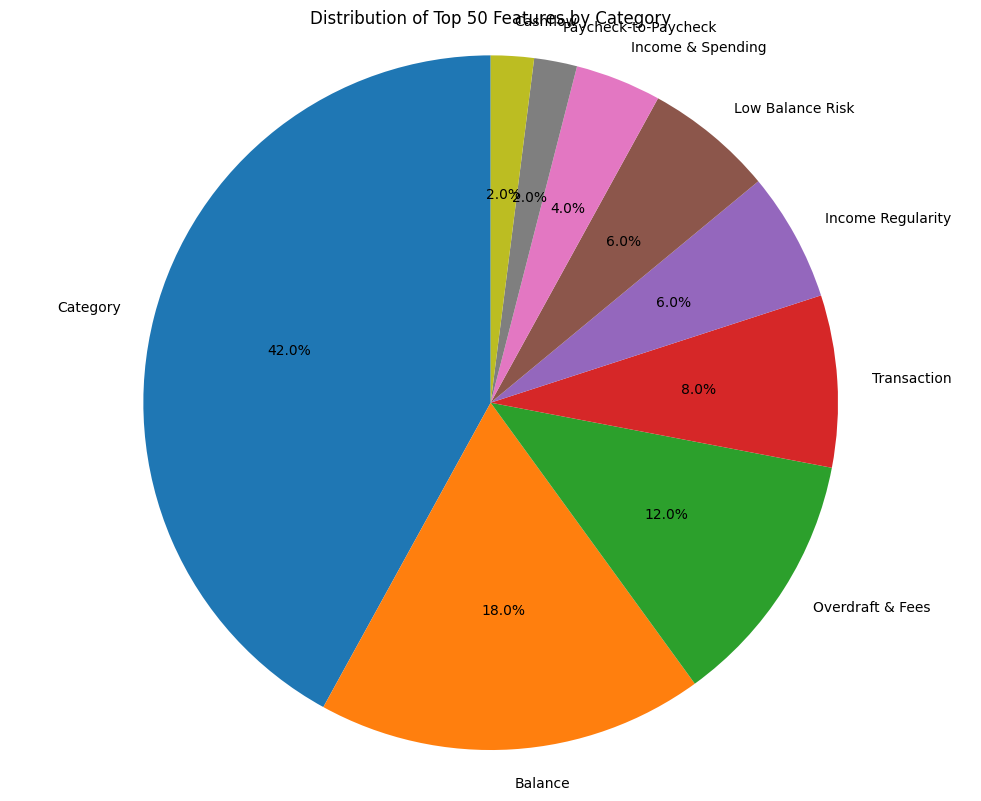

In [15]:
# Export top 50 features for production use
n_final = 50
final_features = consensus_df.head(n_final)['feature'].tolist()

print(f"\nFinal {n_final} selected features:")
print("="*80)
for i, feat in enumerate(final_features, 1):
    print(f"{i:2d}. {feat}")

# Save to file
with open('selected_features_top50.txt', 'w') as f:
    for feat in final_features:
        f.write(feat + '\n')

print("\n✓ Saved to 'selected_features_top50.txt'")

# Create a feature importance visualization by category
top_50_with_scores = consensus_df.head(50).copy()

def categorize_feature(feat_name):
    if 'overdraft' in feat_name or 'fee' in feat_name:
        return 'Overdraft & Fees'
    elif any(x in feat_name for x in ['days_below', 'consecutive_negative', 'zero_crossings']):
        return 'Low Balance Risk'
    elif feat_name.startswith('paycheck__') or 'coefficient_of_variation' in feat_name or 'frequency' in feat_name:
        return 'Income Regularity'
    elif 'before_income' in feat_name or 'depletion' in feat_name:
        return 'Paycheck-to-Paycheck'
    elif feat_name.startswith('balance__'):
        return 'Balance'
    elif feat_name.startswith('cashflow__'):
        return 'Cashflow'
    elif feat_name.startswith('cat_'):
        return 'Category'
    elif feat_name.startswith('income__') or 'spend' in feat_name:
        return 'Income & Spending'
    else:
        return 'Transaction'

top_50_with_scores['category'] = top_50_with_scores['feature'].apply(categorize_feature)

category_counts = top_50_with_scores['category'].value_counts()
print("\nFeature distribution by category (Top 50):")
print(category_counts)

# Pie chart
plt.figure(figsize=(10, 8))
plt.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Top 50 Features by Category')
plt.axis('equal')
plt.tight_layout()
plt.show()

## Summary

This notebook implemented a comprehensive feature selection pipeline:

1. ✅ **Variance Threshold** - Removed near-constant features
2. ✅ **Correlation Filtering** - Removed redundant features (>0.95 correlation)
3. ✅ **Tree-Based Importance** - Gradient boosting built-in importance
4. ✅ **Permutation Importance** - Real impact on predictions
5. ✅ **SHAP Values** - Feature contribution analysis
6. ✅ **Mutual Information** - Non-linear relationships
7. ✅ **Consensus Ranking** - Combined all methods
8. ✅ **Performance Testing** - Validated different feature set sizes

**Key Findings:**
- Started with ~200+ features
- Optimal performance achieved with 50 features
- New risk indicator features (overdraft, low balance, income regularity) are highly predictive
- Final feature list saved for production use